In [ ]:
!pip install netCDF4
!pip install pysolar

     |████████████████████████████████| 51kB 4.6MB/s 


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pysolar.solar import *
import datetime

from google.colab import files

import tensorflow as tf

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Input, Dense, Dropout, Reshape, Flatten, \
    LSTM, GRU, Concatenate, BatchNormalization, TimeDistributed, RepeatVector
from tensorflow.keras.models import Model, load_model

from tensorflow.keras import metrics, losses
from tensorflow.keras import backend as K

tf.test.gpu_device_name()
print(tf.__version__)

2.5.0


In [ ]:

from datetime import datetime, timedelta
from netCDF4 import Dataset

from google.colab import drive, files
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Model Data
#model_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/model_data_new.npy')
model_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/hour_model.npy')

# Obs Data
#obs_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/obs_data_new.npy') 
obs_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/hour_obs.npy') 

# Precomputed SZA
#sza = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/sza_new.npy', allow_pickle=True)
sza = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/hour_sza.npy', allow_pickle=True)

#sh_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/hour_sh.npy')

#cc_data = np.load('/content/gdrive/MyDrive/Colab Notebooks/ERA30MinVertical/hour_t.npy')

In [ ]:
test_data = obs_data[:,0]
print(len(test_data))

98555


In [ ]:
print(obs_data.shape)

(98555, 6)


In [ ]:
# # Start time of dataset
# base = datetime.datetime(2009,1,1,0,0, tzinfo=datetime.timezone.utc) + datetime.timedelta(minutes=20)

# arr = [base + datetime.timedelta(minutes=30*i) for i in range(len(obs_data))]
# sza = np.array([90.0 - get_altitude(48.2082, 16.3738, arr[i]) for i in range(len(obs_data))])
# print(sza.shape)
# np.save('sza_new.npy',sza)

In [ ]:
#Separate data for validation
obs_data_val = obs_data
model_data_val = model_data
sza_val = sza

In [ ]:
obs_data_vis_val = obs_data_val[:,0]
obs_data_T_val = obs_data_val[:,2]
obs_data_Td_val = obs_data_val[:,3]
sza_val = np.repeat(np.expand_dims(sza, -1), 4, axis=1)

model_data_T_val = model_data_val[:,:,1]
model_data_Td_val = model_data_val[:,:,2]

bins = [-1, 350, 800, 1500, 3000, 5000, 10000]
obs_data_vis_val = pd.cut(obs_data_vis_val, bins, labels=[0,1,2,3,4,5]).to_numpy()

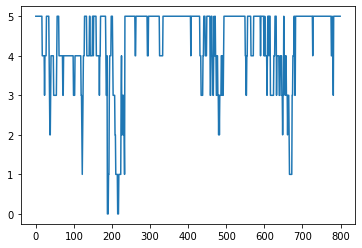

In [ ]:
plt.plot(obs_data_vis_val[200:1000])
plt.show()

In [ ]:
# Extract the individual features
obs_data_vis = obs_data[:,0]
obs_data_ceil = obs_data[:,1]
obs_data_T = obs_data[:,2]
obs_data_Td = obs_data[:,3]
#obs_data_ws = obs_data[:,4]
#obs_data_wd = obs_data[:,5]
#obs_data_sh = sh_data[:,5]
#obs_data_cc_1000 = cc_data[:,12]
#obs_data_cc_975 = cc_data[:,11]

model_data_T = model_data[:,:,1]
model_data_Td = model_data[:,:,2]
#model_data_ws = model_data[:,:,3]
#model_data_wd = model_data[:,:,4]
#model_data_sh = sh_data[:,5]
#model_data_cc_1000 = cc_data[:,12]
#model_data_cc_975 = cc_data[:,11]

sza = np.repeat(np.expand_dims(sza, -1), 4, axis=1)

In [ ]:
# Bin the data
bins = [-1, 350, 800, 1500, 3000, 5000, 10000]
obs_data_vis = pd.cut(obs_data_vis, bins, labels=[0,1,2,3,4,5]).to_numpy()

In [ ]:
# Use the past_history nr of data to predict future_target nr of data
past_history = 6
future_target = 4

In [ ]:
# Split into training data
TRAIN_SPLIT = np.int(0.8*len(obs_data_vis))
print(TRAIN_SPLIT)


78844


In [ ]:
TRAIN_SPLIT_val = np.int(len(obs_data_vis_val)-TRAIN_SPLIT)
print(TRAIN_SPLIT_val)

19711


In [ ]:
def multivariate_data_model(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i+target_size, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)


def multivariate_data_obs(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In [ ]:
STEP = 1

# This is the visibility (target) dataset
x_train_vis, y_train_vis = multivariate_data_obs(obs_data_vis, obs_data_vis, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_vis, y_val_vis = multivariate_data_obs(obs_data_vis_val, obs_data_vis_val,
                                             200, 1000, past_history,
                                             future_target, STEP)

# These are the auxiliary (T, Td, ws, wd, ceil) datasets
x_train_T_obs, _ = multivariate_data_obs(obs_data_T, obs_data_T, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_T_obs, _ = multivariate_data_obs(obs_data_T_val, obs_data_T_val,
                                             200, 1000, past_history,
                                             future_target, STEP)

x_train_Td_obs, _ = multivariate_data_obs(obs_data_Td, obs_data_Td, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_Td_obs, _ = multivariate_data_obs(obs_data_Td_val, obs_data_Td_val,
                                             200, 1000, past_history,
                                             future_target, STEP)

#x_train_ws_obs, _ = multivariate_data_obs(obs_data_ws, obs_data_ws, 0,
#                                                 TRAIN_SPLIT, past_history,
#        
#                                         future_target, STEP)

#x_val_ws_obs, _ = multivariate_data_obs(obs_data_ws, obs_data_ws,
#                                             TRAIN_SPLIT, None, past_history,
#                                             future_target, STEP)

#x_train_wd_obs, _ = multivariate_data_obs(obs_data_wd, obs_data_wd, 0,
#                                                TRAIN_SPLIT, past_history,
#                                                 future_target, STEP)

#x_val_wd_obs, _ = multivariate_data_obs(obs_data_wd, obs_data_wd,
#                                             TRAIN_SPLIT, None, past_history,
#                                             future_target, STEP)

#x_train_ceil_obs, _ = multivariate_data_obs(obs_data_ceil, obs_data_ceil, 0,
#                                                 TRAIN_SPLIT, past_history,
#                                                 future_target, STEP)
#x_val_ceil_obs, _ = multivariate_data_obs(obs_data_ceil, obs_data_ceil,
#                                             TRAIN_SPLIT, None, past_history,
#                                            future_target, STEP)

#sh
#x_train_sh_obs, _ = multivariate_data_obs(obs_data_sh, obs_data_sh, 0,
                                                 #TRAIN_SPLIT, past_history,
                                                 #future_target, STEP)

#x_val_sh_obs, _ = multivariate_data_obs(obs_data_sh, obs_data_sh,
                                             #TRAIN_SPLIT, None, past_history,
                                            #future_target, STEP)

#cc
#x_train_cc_1000_obs, _ = multivariate_data_obs(obs_data_cc_1000, obs_data_cc_1000, 0,
#                                                 TRAIN_SPLIT, past_history,
#                                                 future_target, STEP)

#x_val_cc_1000_obs, _ = multivariate_data_obs(obs_data_cc_1000, obs_data_cc_1000,
#                                             TRAIN_SPLIT, None, past_history,
#                                            future_target, STEP)

#x_train_cc_975_obs, _ = multivariate_data_obs(obs_data_cc_975, obs_data_cc_975, 0,
#                                                 TRAIN_SPLIT, past_history,
#                                                 future_target, STEP)

#x_val_cc_975_obs, _ = multivariate_data_obs(obs_data_cc_975, obs_data_cc_975,
#                                             TRAIN_SPLIT, None, past_history,
#                                            future_target, STEP)



x_train_T_model, _ = multivariate_data_model(model_data_T, model_data_T, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_T_model, _ = multivariate_data_model(model_data_T_val, model_data_T_val,
                                             200, 1000, past_history,
                                             future_target, STEP)

x_train_Td_model, _ = multivariate_data_model(model_data_Td, model_data_Td, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_Td_model, _ = multivariate_data_model(model_data_Td_val, model_data_Td_val,
                                             200, 1000, past_history,
                                             future_target, STEP)

# x_train_p_model, _ = multivariate_data_model(model_data_p, model_data_p, 0,
#                                                  TRAIN_SPLIT, past_history,
#                                                  future_target, STEP)
# x_val_p_model, _ = multivariate_data_model(model_data_p, model_data_p,
#                                              TRAIN_SPLIT, None, past_history,
#                                              future_target, STEP)

#x_train_ws_model, _ = multivariate_data_model(model_data_ws, model_data_ws, 0,
#                                                TRAIN_SPLIT, past_history,
#                                                 future_target, STEP)

#x_val_ws_model, _ = multivariate_data_model(model_data_ws, model_data_ws,
#                                             TRAIN_SPLIT, None, past_history,
#                                            future_target, STEP)

#x_train_wd_model, _ = multivariate_data_model(model_data_wd, model_data_wd, 0,
                                                 #TRAIN_SPLIT, past_history,
                                                 #future_target, STEP)
#x_val_wd_model, _ = multivariate_data_model(model_data_wd, model_data_wd,
                                             #TRAIN_SPLIT, None, past_history,
                                             #future_target, STEP)

x_train_sza, _ = multivariate_data_model(sza, sza, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_sza, _ = multivariate_data_model(sza_val, sza_val,
                                             200, 1000, past_history,
                                             future_target, STEP)

#sh
#x_train_sh_model, _ = multivariate_data_model(model_data_sh, model_data_sh, 0,
                                                 #TRAIN_SPLIT, past_history,
                                                 #future_target, STEP)

#x_val_sh_model, _ = multivariate_data_model(model_data_sh, model_data_sh,
                                             #TRAIN_SPLIT, None, past_history,
                                             #future_target, STEP)

#cc
#x_train_cc_1000_model, _ = multivariate_data_model(model_data_cc_1000, model_data_cc_1000, 0,
#                                                 TRAIN_SPLIT, past_history,
#                                                 future_target, STEP)

#x_val_cc_1000_model, _ = multivariate_data_model(model_data_cc_1000, model_data_cc_1000,
#                                             TRAIN_SPLIT, None, past_history,
#                                             future_target, STEP)

#x_train_cc_975_model, _ = multivariate_data_model(model_data_cc_975, model_data_cc_975, 0,
#                                                 TRAIN_SPLIT, past_history,
#                                                 future_target, STEP)

#x_val_cc_975_model, _ = multivariate_data_model(model_data_cc_975, model_data_cc_975,
#                                            TRAIN_SPLIT, None, past_history,
#                                             future_target, STEP)

(array([  544.,   894.,     0.,   649.,  1685.,     0.,  4194., 70872.]),
 array([0.   , 0.625, 1.25 , 1.875, 2.5  , 3.125, 3.75 , 4.375, 5.   ]),
 <a list of 8 Patch objects>)

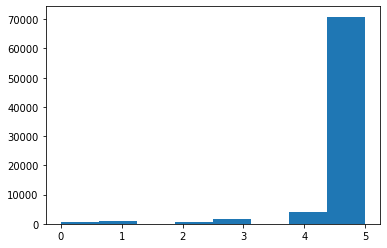

In [ ]:
plt.hist(x_train_vis[:,0],bins=8)

In [ ]:
print(np.count_nonzero(x_train_vis[:,0] == 2))

649


In [ ]:
# Using T-Td as feature
x_train_TTd_obs = x_train_T_obs-x_train_Td_obs
x_val_TTd_obs = x_val_T_obs-x_val_Td_obs

x_train_TTd_model = x_train_T_model-x_train_Td_model
x_val_TTd_model = x_val_T_model-x_val_Td_model

In [ ]:
# Normalize the feature
TTd_max = np.max(x_train_TTd_obs)
TTd_min = np.min(x_train_TTd_obs)

T_max = np.max(x_train_T_obs) 
T_min = np.min(x_train_T_obs) 

#ws_max = np.max(x_train_ws_obs) 
#ws_min = np.min(x_train_ws_obs)

#wd_max = np.max(x_train_wd_obs) 
#wd_min = np.min(x_train_wd_obs) 

#ceil_max = np.max(x_train_ceil_obs) 
#ceil_min = np.min(x_train_ceil_obs)

#sh_max = np.max(x_train_sh_obs)
#sh_min = np.min(x_train_sh_model)

#cc_1000_max = np.max(x_train_cc_1000_obs)
#cc_1000_min = np.min(x_train_cc_1000_model)

#cc_975_max = np.max(x_train_cc_975_obs)
#cc_975_min = np.min(x_train_cc_975_model)


# p_max = np.max(x_train_p_model) 
# p_min = np.min(x_train_p_model) 

sza_max = np.max(x_train_sza) 
sza_min = np.min(x_train_sza) 

x_train_TTd_obs = (x_train_TTd_obs - TTd_min)/(TTd_max - TTd_min)
x_val_TTd_obs = (x_val_TTd_obs - TTd_min)/(TTd_max - TTd_min)

x_train_TTd_model = (x_train_TTd_model - TTd_min)/(TTd_max - TTd_min)
x_val_TTd_model = (x_val_TTd_model - TTd_min)/(TTd_max - TTd_min)

x_train_T_obs = (x_train_T_obs - T_min)/(T_max - T_min)
x_val_T_obs = (x_val_T_obs - T_min)/(T_max - T_min)

x_train_T_model = (x_train_T_model - T_min)/(T_max - T_min)
x_val_T_model = (x_val_T_model - T_min)/(T_max - T_min)

# x_train_p_model = (x_train_p_model - p_min)/(p_max - p_min)
# x_val_p_model = (x_val_p_model - p_min)/(p_max - p_min)

#x_train_ws_obs = (x_train_ws_obs - ws_min)/(ws_max - ws_min)
#x_val_ws_obs = (x_val_ws_obs - ws_min)/(ws_max - ws_min)

#x_train_wd_obs = (x_train_wd_obs - wd_min)/(wd_max - wd_min)
#x_val_wd_obs = (x_val_wd_obs - wd_min)/(wd_max - wd_min)

#x_train_ceil_obs = (x_train_ceil_obs - ceil_min)/(ceil_max - ceil_min)
#x_val_ceil_obs = (x_val_ceil_obs - ceil_min)/(ceil_max - ceil_min)

#x_train_sh_obs = (x_train_sh_obs - sh_min)/(sh_max - sh_min)
#x_val_sh_obs = (x_val_sh_obs - sh_min)/(sh_max - sh_min)

#x_train_cc_1000_obs = (x_train_cc_1000_obs - cc_1000_min)/(cc_1000_max - cc_1000_min)
#x_val_cc_1000_obs = (x_val_cc_1000_obs - cc_1000_min)/(cc_1000_max - cc_1000_min)

#x_train_cc_975_obs = (x_train_cc_975_obs - cc_1000_min)/(cc_975_max - cc_975_min)
#x_val_cc_975_obs = (x_val_cc_975_obs - cc_975_min)/(cc_975_max - cc_975_min)

x_train_sza = (x_train_sza - sza_min)/(sza_max - sza_min)
x_val_sza = (x_val_sza - sza_min)/(sza_max - sza_min)

In [ ]:
print(x_val_T_model.shape)
print(x_val_TTd_model.shape)
print(x_val_sza.shape)

(794, 10, 4)
(794, 10, 4)
(794, 10, 4)


In [ ]:
# Concatenate the data
x_train_model = np.concatenate((x_train_T_model, x_train_TTd_model, x_train_sza), axis=2)

x_val_model = np.concatenate((x_val_T_model, x_val_TTd_model, x_val_sza), axis=2)

x_train_obs = np.stack((x_train_vis, x_train_TTd_obs), axis=2)
x_val_obs = np.stack((x_val_vis, x_val_TTd_obs), axis=2)

# x_train_obs = np.stack((x_train_vis, x_train_ceil_obs, x_train_TTd_obs, x_train_T_obs, 
#                         x_train_ws_obs, x_train_wd_obs), axis=2)
# x_val_obs = np.stack((x_val_vis, x_val_ceil_obs, x_val_TTd_obs, x_val_T_obs,
#                       x_val_ws_obs, x_val_wd_obs), axis=2)

In [ ]:
print(x_train_model.shape)
print(x_train_obs.shape)

(78838, 10, 12)
(78838, 6, 2)


In [ ]:
# Total number of model features
nr_features_model = x_train_model.shape[2]
nr_features_obs = x_train_obs.shape[2]

In [ ]:
# Data shape
print ('Single window of past history : {}'.format(x_train_model[0].shape))
print ('Target visibility to predict : {}'.format(y_train_vis[0].shape))

Single window of past history : (10, 12)
Target visibility to predict : (4,)


In [ ]:
def multi_layer_cross_entropy(y_true, y_pred):

  t = np.ones(future_target)

  loss = t[0]*tf.keras.losses.sparse_categorical_crossentropy(y_true[:,0], y_pred[:,0,:])

  for i in range(1, future_target):
    y_true_step_i = y_true[:,i]
    y_pred_step_i = y_pred[:,i,:]
    loss += t[i]*tf.keras.losses.sparse_categorical_crossentropy(y_true_step_i, 
                                                              y_pred_step_i)
  
  
  return loss

In [ ]:
input_shape_model = (past_history+future_target, nr_features_model,)
input_shape_obs = (past_history, nr_features_obs,)

# Obs branch
in_obs = Input(shape=input_shape_obs)
b_obs = LSTM(128, return_sequences=False, recurrent_dropout=0.0, 
                   dropout=0.)(in_obs)

# Model branch
in_model = Input(shape=input_shape_model)
b_model = LSTM(128, return_sequences=False, recurrent_dropout=0.0, 
                   dropout=0.)(in_model)               

# Now concatenate with all branches
b = Concatenate()([b_obs, b_model])
b = Dense(128*future_target, activation='selu')(b)
b = Dropout(0.5)(b)
b = Reshape((future_target, 128))(b)
b = LSTM(128, return_sequences=True, recurrent_dropout=0.0)(b)
out = TimeDistributed(Dense(8, activation='softmax'))(b)

model = Model([in_obs, in_model], out)
model.compile(optimizer='adam', loss=multi_layer_cross_entropy,
              metrics=['acc'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 6, 2)]       0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 10, 12)]     0                                            
__________________________________________________________________________________________________
lstm (LSTM)                     (None, 128)          67072       input_1[0][0]                    
__________________________________________________________________________________________________
lstm_1 (LSTM)                   (None, 128)          72192       input_2[0][0]                    
______________________________________________________________________________________________

In [ ]:
multi_step_history = model.fit([x_train_obs, x_train_model], 
                               y_train_vis, batch_size=256,
                               validation_split=0.05, epochs=40,
                               callbacks=tf.keras.callbacks.EarlyStopping(patience=5))

Epoch 1/40
293/293 [==============================] - 13s 12ms/step - loss: 1.2790 - acc: 0.9065 - val_loss: 0.6850 - val_acc: 0.9443
Epoch 2/40
293/293 [==============================] - 3s 9ms/step - loss: 0.9436 - acc: 0.9204 - val_loss: 0.6777 - val_acc: 0.9446
Epoch 3/40
293/293 [==============================] - 3s 9ms/step - loss: 0.9210 - acc: 0.9223 - val_loss: 0.6448 - val_acc: 0.9491
Epoch 4/40
293/293 [==============================] - 3s 9ms/step - loss: 0.9087 - acc: 0.9231 - val_loss: 0.6362 - val_acc: 0.9491
Epoch 5/40
293/293 [==============================] - 3s 9ms/step - loss: 0.8976 - acc: 0.9239 - val_loss: 0.6281 - val_acc: 0.9495
Epoch 6/40
293/293 [==============================] - 3s 9ms/step - loss: 0.8892 - acc: 0.9242 - val_loss: 0.6227 - val_acc: 0.9505
Epoch 7/40
293/293 [==============================] - 3s 9ms/step - loss: 0.8832 - acc: 0.9244 - val_loss: 0.6131 - val_acc: 0.9502
Epoch 8/40
293/293 [==============================] - 3s 9ms/step - loss: 

In [ ]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

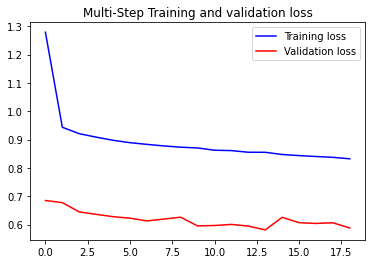

In [ ]:
plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

Text(0, 0.5, 'class')

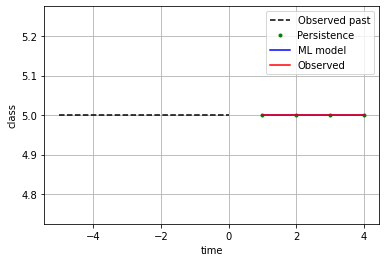

In [ ]:
# Plot some results
ix = np.random.randint(0, len(x_val_vis))

vis = np.expand_dims(x_val_vis[ix,], axis=0)
true_vis = np.expand_dims(y_val_vis[ix,], axis=0)
data_obs = np.expand_dims(x_val_obs[ix,], axis=0)
data_model = np.expand_dims(x_val_model[ix,], axis=0)
# sza = np.expand_dims(x_val_sza[ix,], axis=0)

runs = 20
vis_prob = np.stack([model([data_obs, data_model], training=True) \
                     for sample in range(runs)])
vis_prob = np.argmax(vis_prob, axis=3)

vis_mean = np.round(vis_prob.mean(axis=0))
vis_std = vis_prob.std(axis=0)

# This is the input observations
plt.plot(np.arange(-past_history+1, 1), vis[0,:past_history],'k--')

# Persitence prediction
plt.plot(np.arange(1, future_target+1), x_val_vis[ix, past_history-1]*np.ones(future_target),'g.')

# ML prediction
plt.plot(np.arange(1, future_target+1), vis_mean[0,],'b')
plt.fill_between(np.arange(1, future_target+1), vis_mean[0,]-vis_std[0,], vis_mean[0,]+vis_std[0,])

# True observed future
plt.plot(np.arange(1, future_target+1), true_vis[0,],'r')

plt.legend(['Observed past','Persistence','ML model','Observed']) 
plt.grid()
plt.xlabel('time')
plt.ylabel('class')

# for i in range(runs):
#  plt.plot(np.arange(0, future_target), np.round(vis_prob[i,0,]),'r-.')

In [ ]:
res = model([data_obs, data_model], training=True)[0,].numpy()
print(res.sum(axis=1))

[1.         1.         1.         0.99999994]


In [ ]:
# Proper verification
from sklearn.metrics import *

In [ ]:
# Now verify the model
n_val = len(x_val_vis)
y_pers = np.zeros((n_val, future_target))
y_ml = np.zeros((n_val, future_target))

err_pers = np.zeros(n_val)
err_ml = np.zeros(n_val)

for i in range(n_val):

  # 1) Persistence error
  y_pers[i,] = x_val_vis[i, past_history-1]*np.ones(future_target)
  err_pers[i] = np.mean(np.square(y_pers[i,] - y_val_vis[i,]))

  # 3) ML model error
  vis = np.expand_dims(x_val_vis[i,], axis=0)
  true_vis = np.expand_dims(y_val_vis[i,], axis=0)
  data_obs = np.expand_dims(x_val_obs[i,], axis=0)
  data_model = np.expand_dims(x_val_model[i,], axis=0)

  vis_ml = model([data_obs, data_model])
  vis_ml = np.argmax(vis_ml, axis=2)
  
  err_ml[i] = np.mean(np.square(vis_ml[0,] - y_val_vis[i,]))
  y_ml[i,:] = vis_ml[0,]

print('Persistence error: {}'.format(np.sum(err_pers)))
print('ML model error: {}'.format(np.sum(err_ml)))

Persistence error: 422.0
ML model error: 343.5


In [ ]:
nr_classes = 8

precision_pers = np.zeros((nr_classes,future_target))
recall_pers = np.zeros((nr_classes,future_target))
f1_pers = np.zeros((nr_classes,future_target))
balanced_acc_pers = np.zeros(future_target)

precision_ml = np.zeros((nr_classes,future_target))
recall_ml = np.zeros((nr_classes,future_target))
f1_ml = np.zeros((nr_classes,future_target))
balanced_acc_ml = np.zeros(future_target)

for i in range(future_target):
  precision_pers[:,i] = precision_score(y_val_vis[:,i], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  precision_ml[:,i] = precision_score(y_val_vis[:,i], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)

  recall_pers[:,i] = recall_score(y_val_vis[:,i], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  recall_ml[:,i] = recall_score(y_val_vis[:,i], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)

  f1_pers[:,i] = f1_score(y_val_vis[:,i], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  f1_ml[:,i] = f1_score(y_val_vis[:,i], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  
  balanced_acc_pers[i] = balanced_accuracy_score(y_val_vis[:,i], y_pers[:,i])
  balanced_acc_ml[i] = balanced_accuracy_score(y_val_vis[:,i], y_ml[:,i])

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1515: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  average, "true nor predicted", 'F-score is', len(true_sum)


In [ ]:
def categorical_skill_scores(y_true, y_pred, labels=[0,1,2,3,4,5,6,7]):

  # Compute the confusion matrix
  C = confusion_matrix(y_true, y_pred, labels=labels)
  C = C.transpose()
  nr_fcst = np.sum(C, axis=1)
  nr_obs = np.sum(C, axis=0)
  N = np.sum(nr_obs)

  # Heidke skill score
  HSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_fcst*nr_obs))

  # Peirce skill score
  PSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_obs**2))

  return HSS, PSS

In [ ]:
np.set_printoptions(precision=2)
for i in range(future_target):
  HSS, PSS = categorical_skill_scores(y_val_vis[:,i],y_ml[:,i])
  print('Prediction step {}:'.format(i+1))
  print('F1-score ML: {}'.format(f1_ml[:,i]))
  print('F1-score PE: {}'.format(f1_pers[:,i]))
  print('Balanced accuracy ML: {}'.format(np.round(100*balanced_acc_ml[i])/100.0))
  print('Balanced accuracy PE: {}'.format(np.round(100*balanced_acc_pers[i])/100.0))
  print('Heidke skill score ML: {}\nPeirce skill score ML: {}'.format(HSS, PSS))
  HSS, PSS = categorical_skill_scores(y_val_vis[:,i],y_pers[:,i])
  print('Heidke skill score PE: {}\nPeirce skill score PE: {}\n'.format(HSS, PSS))

Prediction step 1:
F1-score ML: [0.67 0.74 0.27 0.58 0.74 0.93 0.   0.  ]
F1-score PE: [0.67 0.73 0.27 0.58 0.73 0.93 0.   0.  ]
Balanced accuracy ML: 0.65
Balanced accuracy PE: 0.65
Heidke skill score ML: 0.6981231562500866
Peirce skill score ML: 0.6965785932247505
Heidke skill score PE: 0.6943938328284477
Peirce skill score PE: 0.6943938328284477

Prediction step 2:
F1-score ML: [0.4  0.67 0.17 0.44 0.62 0.89 0.   0.  ]
F1-score PE: [0.33 0.55 0.13 0.37 0.59 0.89 0.   0.  ]
Balanced accuracy ML: 0.51
Balanced accuracy PE: 0.48
Heidke skill score ML: 0.5738598646949986
Peirce skill score ML: 0.562541189240678
Heidke skill score PE: 0.5294984188869629
Peirce skill score PE: 0.5294984188869629

Prediction step 3:
F1-score ML: [0.2  0.6  0.17 0.38 0.57 0.87 0.   0.  ]
F1-score PE: [0.   0.41 0.   0.33 0.55 0.86 0.   0.  ]
Balanced accuracy ML: 0.44
Balanced accuracy PE: 0.36
Heidke skill score ML: 0.506535777673714
Peirce skill score ML: 0.48522171579839274
Heidke skill score PE: 0.46134

In [ ]:
for i in range(future_target):
  print('Classification summary ML model at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_val_vis[:,i], y_ml[:,i], labels=[0,1,2,3,4,5]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_val_vis[:,i], y_ml[:,i], labels=[0,1,2,3,4,5]))
  print('\n-----------------------------------------------------------')
  print('-----------------------------------------------------------\n')
  print('Classification summary Persistence at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_val_vis[:,i], y_pers[:,i], labels=[0,1,2,3,4,5]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_val_vis[:,i], y_pers[:,i], labels=[0,1,2,3,4,5]))  
  print('\n')

Classification summary ML model at forecast hour 1:

              precision    recall  f1-score   support

           0       0.67      0.67      0.67         6
           1       0.76      0.73      0.74        22
           2       0.27      0.27      0.27        15
           3       0.60      0.56      0.58        86
           4       0.72      0.75      0.74       191
           5       0.93      0.93      0.93       474

    accuracy                           0.83       794
   macro avg       0.66      0.65      0.65       794
weighted avg       0.83      0.83      0.83       794

Confusion matrix:

[[  4   1   0   0   1   0]
 [  2  16   4   0   0   0]
 [  0   1   4   9   1   0]
 [  0   2   7  48  25   4]
 [  0   0   0  20 143  28]
 [  0   1   0   3  28 442]]

-----------------------------------------------------------
-----------------------------------------------------------

Classification summary Persistence at forecast hour 1:

              precision    recall  f1-score 